In [116]:
# from dnn_app_utils_v3 import *
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from matplotlib.pyplot import *
import matplotlib.pyplot as plt
import tensorflow as tf
import PIL
from PIL import Image
from numpy import asarray
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from IPython.display import Image, display

## Creates Model using 3 layers of CNN and Pooling followed by a two layered neural network

### Then creates datagenerator for tests and training sets

##### Creates final model called 'history'

In [117]:
import os
from tensorflow.keras.optimizers import RMSprop
# train_horse_dir = os.path.join(r 'C:\Users\91762\Jupyter\iris\horse-or-human\horses')
# train_human_dir = os.path,join('C:\Users\91762\Jupyter\iris\horse-or-human\humans')

if os.stat("rps.h5").st_size != 0:

    print('The model is saved with the name rps.h5. Load this model.')
    print('The next line will prevent the model from training again')
    print('HAVING THE ERROR IS A GOOD THING')
    assert(False)


model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3),  activation='relu', input_shape=(300,300,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(32, (3,3),  activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64, (3,3),  activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64, (3,3),  activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation = 'relu'),
    tf.keras.layers.Dense(3, activation = 'softmax')
])

model.compile(loss = 'sparse_categorical_crossentropy',
             optimizer = RMSprop(lr = 0.001),
             metrics = ['accuracy']
             )
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    rotation_range = 40,
    width_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range =0.2,
    horizontal_flip = True,
    fill_mode = 'nearest'
    ) #normalizing data
train_generator = train_datagen.flow_from_directory(
        'A:/python_data/rock-paper-scissors/training',  # This is the source directory for training images
        target_size=(300, 300),  # All images will be resized to 150x150
        batch_size=126,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode="categorical")

validation_datagen = ImageDataGenerator(
    rescale=1 / 255,
    rotation_range=40,
    width_shift_range=.2,
    height_shift_range=.2,
    shear_range=.2,
    zoom_range=.2,
    horizontal_flip=True,
    fill_mode='nearest'

)
validation_generator = validation_datagen.flow_from_directory(
    'A:/python_data/rock-paper-scissors/testing',
    batch_size=126,
    class_mode='categorical',
    target_size=(300, 300)
)


history = model.fit(
    train_generator,
    steps_per_epoch = 20, #make this 40
    epochs = 25,
    verbose = 1,
    validation_data=validation_generator
)

model.save('rps.h5')

# Found 2520 images belonging to 3 classes.
# Found 372 images belonging to 3 classes.



The model is saved with the name rps.h5. Load this model.
The next line will prevent the model from training again
HAVING THE ERROR IS A GOOD THING


AssertionError: 

## Loading the model from the file 'rps.h5'

In [118]:
model = tf.keras.models.load_model('rps.h5')

## Defined predictor function used to predict images of our own

#### Specify img_dir to try different images

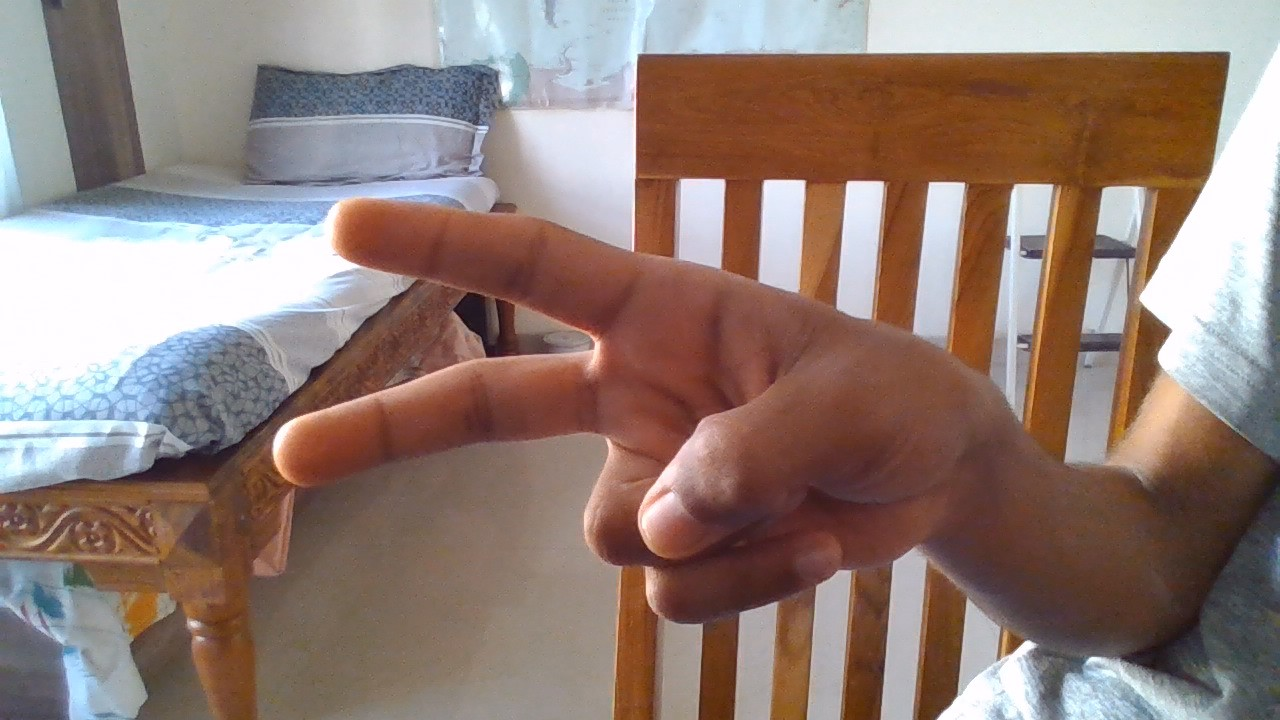

The class of the image is  [1. 0. 0.]
The image is of a hand showing paper
The corresponding classes are [paper, rock, scissors]


In [126]:
from keras.preprocessing import image
from PIL import Image  
from IPython.display import Image, display



img_dir = 'A:/delete/scissor2_camera.jpg' #CHANGE THIS TO TRY DIFFERENT IMAGES!

def predictor(img_dir):
    img = image.load_img(img_dir, target_size = (300,300))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis = 0) #increases the dimension of the array by one. if 1D, becomes 2D.
                                    #axis = 0 ==> shape = (1, length)
                                    #here, it changes shape from (300, 300, 3) to (1,300,300,3)
    images = np.vstack([x]) #stacks the array vertically (the shape does not change for some reason)
    classes = model.predict(images, batch_size = 10)

    print('The class of the image is ', np.squeeze(classes[0]))
    
    classes = np.squeeze(classes[0])
    if classes[0] == 1:
        print("The image is of a hand showing paper")
        
    elif classes[1] == 1:
        print("The image is of a hand showing rock")
        
    else:
        print("The image is of a hand showing scissors")
    
        
display(Image(filename=img_dir))
predictor(img_dir)
print('The corresponding classes are [paper, rock, scissors]')

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


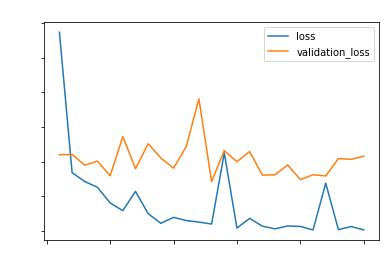

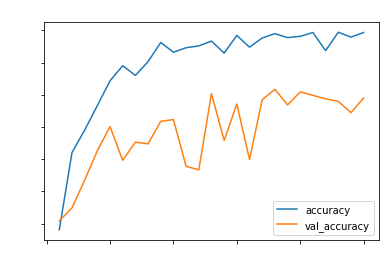

In [113]:

print(history.history.keys())

accuracy = history.history['accuracy']
val_accuracy = history.history['accuracy']
# plt.figure()
x = range(1,26)

plt.plot(x, history.history['loss'])
plt.plot(x, history.history['val_loss'])
plt.legend(['loss', 'validation_loss'])
plt.xlabel('No. of Epochs', color = 'white')
plt.ylabel('Loss', color = 'white')
plt.title('Loss Chart', color = 'white')
plt.xticks(color = 'white')
plt.yticks(color = 'white')

plt.figure()
plt.plot(x, history.history['accuracy'])
plt.plot(x, history.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.xlabel('No. of Epochs', color = 'white')
plt.ylabel('Percentage', color = 'white')
plt.title('Accuracy Chart', color = 'white')
plt.xticks(color = 'white')
plt.yticks(color = 'white');
